# 🐼 Notebook 02 — Exploration avec pandas
**Projet fil rouge MobiGreen Urban | Module SQL — Kit 2, Itération 2**

---

## Objectifs
- Charger des données PostgreSQL directement dans des **DataFrames pandas**
- Effectuer une analyse exploratoire de vos données MobiGreen
- Produire des **visualisations** avec matplotlib

## Pré-requis
- Notebook 01 terminé
- `pip install pandas matplotlib` (déjà fait via le projet GitHub)

---

## 1. Imports et connexion

**À faire :** Importez `pandas`, `matplotlib.pyplot`, `psycopg2`, `os` et `dotenv`.

Chargez les variables d'environnement depuis le fichier `.env` à la racine du projet, puis créez une fonction `get_conn()` qui retourne une connexion psycopg2 en utilisant les variables `DB_NAME`, `DB_USER`, `DB_PASSWORD`, `DB_HOST` et `DB_PORT`.

> ⚠️ **Rappel :** Ne codez **jamais** vos identifiants en dur. Utilisez `os.getenv()` après avoir chargé le `.env` avec `load_dotenv()`.

```python
from dotenv import load_dotenv
import os

load_dotenv("../.env")
```

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import psycopg2
import os
from dotenv import load_dotenv
from contextlib import contextmanager

load_dotenv("../.env")

DB_CONFIG = {
    "dbname":   os.getenv("DB_NAME"),
    "user":     os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD"),
    "host":     os.getenv("DB_HOST"),
    "port":     os.getenv("DB_PORT"),
    
}


@contextmanager
def get_cursor():
    conn = psycopg2.connect(**DB_CONFIG)
    cur = conn.cursor()
    try:
        yield cur
        conn.commit()
    except Exception as e:
        conn.rollback()
        print(f"Rollback — erreur : {e}")
        raise
    finally:
        cur.close()
        conn.close()

def exec_query(sql, params=None):
    with get_cursor() as cur:
        cur.execute(sql, params)
        columns = [desc[0] for desc in cur.description]
        rows = cur.fetchall()
    return columns, rows

## 2. Chargement des tables dans des DataFrames

**À faire :** Utilisez `pd.read_sql_query()` pour charger chacune de vos tables principales dans un DataFrame distinct.

Pour au moins une table, écrivez une requête avec jointure directement dans le `read_sql_query` afin d'enrichir les données récupérées.

> 💡 Rappel : `pd.read_sql_query("SELECT ...", conn)` accepte une connexion psycopg2 comme second argument.

Affichez le `.shape` et `.head()` de chaque DataFrame pour vérifier le chargement.

In [75]:
def get_conn():
    return psycopg2.connect(**DB_CONFIG)
def read_sql(sql, params=None):
    cols, rows = exec_query(sql, params)
    df = pd.DataFrame(rows, columns=cols)
    return df
# Chargement de toutes les tables principales en une seule cellule
df_utilisateurs  = read_sql("SELECT * FROM utilisateurs  ORDER BY date_inscription;")
df_abonnements   = read_sql("SELECT * FROM abonnements   ORDER BY date_debut;")
df_vehicules     = read_sql("SELECT * FROM vehicules      ORDER BY type;")
df_stations      = read_sql("SELECT * FROM stations       ORDER BY nom;")
df_trajets       = read_sql("SELECT * FROM trajets        ORDER BY date_debut;")
df_paiements     = read_sql("SELECT * FROM paiements      ORDER BY date_paiement;")
df_incidents     = read_sql("SELECT * FROM incidents      ORDER BY date_signalement;")
df_air           = read_sql("SELECT * FROM donnees_airs   ORDER BY horodatage;")
df_meteo         = read_sql("SELECT * FROM donnees_meteos ORDER BY horodatage;")
df_zones         = read_sql("SELECT * FROM zones_metro;")

# Résumé des chargements
datasets = {
    "utilisateur":  df_utilisateurs,
    "abonnement":   df_abonnements,
    "vehicule":     df_vehicules,
    "station":      df_stations,
    "trajet":       df_trajets,
    "paiement":     df_paiements,
    "incident":     df_incidents,
    "donnees_air":  df_air,
    "donnees_meteo":df_meteo,
    "zone":         df_zones,
}

print(f"{'Table':<20} {'Lignes':>6}  {'Colonnes':>8}")
print("-" * 38)
for name, df in datasets.items():
    print(f"  {name:<18} {len(df):>6}  {len(df.columns):>8}")

Table                Lignes  Colonnes
--------------------------------------
  utilisateur            10        10
  abonnement             10         9
  vehicule               15         8
  station                 7        10
  trajet                 20        10
  paiement                7         9
  incident                5         9
  donnees_air             5         8
  donnees_meteo          10         9
  zone                    5         4


## 3. Analyse exploratoire

**À faire :** Sur au moins deux de vos DataFrames, effectuez une analyse exploratoire complète :

- Statistiques descriptives des colonnes numériques (`.describe()`)
- Vérification des valeurs manquantes (`.isnull().sum()`)
- Distribution d'une colonne catégorielle (`.value_counts()`)
- Regroupement avec `.groupby()` et une fonction d'agrégation (`.mean()`, `.count()`, `.sum()`)

In [76]:
#Aperçu de la table trajets
#print("=== df_trajets.head() ===")
#display(df_trajets.head())

#print("\n=== Infos générales ===")
#df_trajets.info()

print("=== Analyse de df_stations ===\n")

# 1. Statistiques descriptives pour les colonnes numériques
print("Statistiques descriptives :")
print(df_stations.describe())
print("\n")

# 2. Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df_stations.isnull().sum())
print("\n")

# 3. Distribution d'une colonne catégorielle (ex: zone_id)
print("Distribution par zone_id :")
print(df_stations['zone_id'].value_counts())
print("\n")

# 4. Regroupement par zone et calcul de la capacité moyenne et totale
print("Capacité moyenne et totale par zone :")
grouped = df_stations.groupby('zone_id').agg({
    'capacite_totale': ['mean', 'sum'],
    'places_disponibles': 'sum'
})
print(grouped)

=== Analyse de df_stations ===

Statistiques descriptives :
       station_id   zone_id  capacite_totale  places_disponibles   latitude  \
count    7.000000  7.000000         7.000000             7.00000   7.000000   
mean     4.000000  2.428571        14.142857             8.00000  45.186214   
std      2.160247  1.618347         5.956189             5.09902   0.018825   
min      1.000000  1.000000         8.000000             3.00000  45.148800   
25%      2.500000  1.000000        10.000000             4.50000  45.182950   
50%      4.000000  2.000000        12.000000             7.00000  45.192000   
75%      5.500000  3.500000        17.000000             9.50000  45.193650   
max      7.000000  5.000000        25.000000            18.00000  45.209500   

       longitude  
count   7.000000  
mean    5.730386  
std     0.030392  
min     5.689000  
25%     5.714850  
50%     5.724400  
75%     5.748250  
max     5.773100  


Valeurs manquantes par colonne :
station_id            

In [77]:
print("=== Analyse de df_trajets ===\n")

# 1. Statistiques descriptives pour colonnes numériques
print("Statistiques descriptives :")
print(df_trajets.describe())
print("\n")

# 2. Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df_trajets.isnull().sum())
print("\n")

# 3. Distribution d'une colonne catégorielle (ex: type de véhicule si existant)
if 'vehicule_id' in df_trajets.columns:
    print("Nombre de trajets par véhicule :")
    print(df_trajets['vehicule_id'].value_counts())
    print("\n")

# 4. Regroupement par utilisateur et calcul du nombre total de trajets
if 'utilisateur_id' in df_trajets.columns:
    grouped_trajets = df_trajets.groupby('utilisateur_id').agg({
        'trajet_id': 'count',
        'duree_minutes': 'mean'  
    })
    print("Nombre et durée moyenne de trajets par utilisateur :")
    print(grouped_trajets.head())

=== Analyse de df_trajets ===

Statistiques descriptives :
       trajet_id  utilisateur_id  vehicule_id  duree_minutes
count   20.00000       20.000000    20.000000      17.000000
mean    10.50000        5.500000     7.100000      27.647059
std      5.91608        2.946898     4.266146      12.761961
min      1.00000        1.000000     1.000000       5.000000
25%      5.75000        3.000000     3.750000      20.000000
50%     10.50000        5.500000     6.500000      25.000000
75%     15.25000        8.000000    10.250000      35.000000
max     20.00000       10.000000    15.000000      50.000000


Valeurs manquantes par colonne :
trajet_id          0
utilisateur_id     0
vehicule_id        0
date_debut         0
date_fin           3
duree_minutes      3
distance_km        3
montant_facture    3
statut             0
created_at         0
dtype: int64


Nombre de trajets par véhicule :
vehicule_id
2     2
3     2
4     2
6     2
7     2
1     1
8     1
9     1
10    1
11    1
12    1

## 4. Visualisations

**À faire :** Produisez **au moins trois graphiques** différents à partir de vos données MobiGreen. Choisissez des représentations adaptées aux données que vous voulez mettre en valeur.

> Types de graphiques disponibles :
> - `plt.hist()` ou `.plot(kind='hist')` → distribution d'une variable numérique
> - `plt.bar()` ou `.plot(kind='bar')` → comparaison de catégories
> - `plt.scatter()` → relation entre deux variables numériques
> - `plt.pie()` ou `.plot(kind='pie')` → répartition en proportions

Chaque graphique doit avoir un **titre**, des **labels d'axes** et être lisible sans explication supplémentaire.

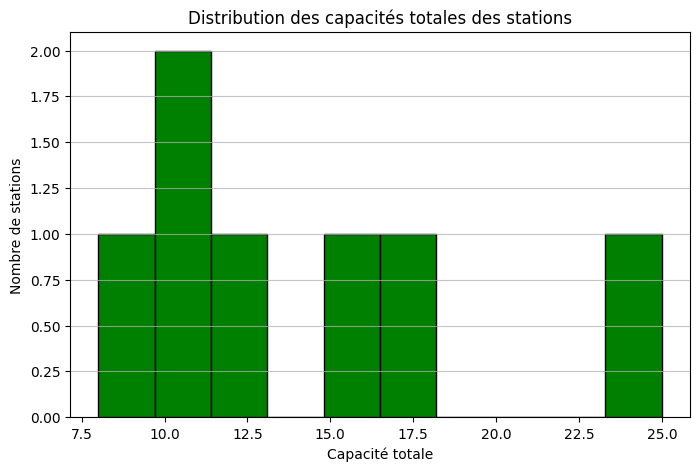

In [100]:
# Histogramme : distribution des capacités des stations

plt.figure(figsize=(8,5))
plt.hist(df_stations['capacite_totale'], bins=10, color='green', edgecolor='black')
plt.title("Distribution des capacités totales des stations")
plt.xlabel("Capacité totale")
plt.ylabel("Nombre de stations")
plt.grid(axis='y', alpha=0.75)
plt.show()

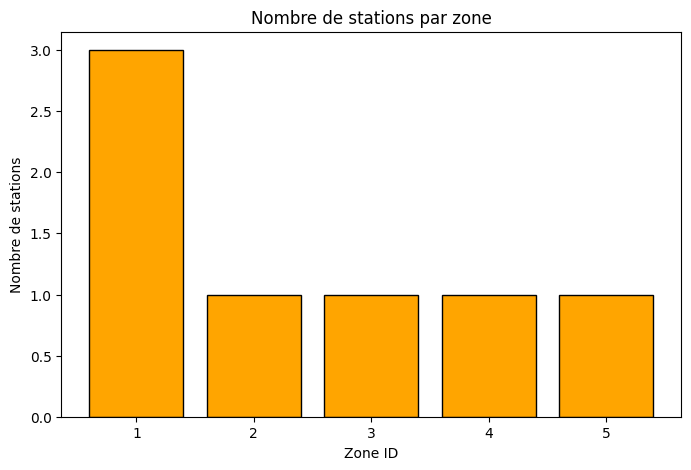

In [79]:
#Barplot : nombre de stations par zone
zone_counts = df_stations['zone_id'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(zone_counts.index.astype(str), zone_counts.values, color='orange', edgecolor='black')
plt.title("Nombre de stations par zone")
plt.xlabel("Zone ID")
plt.ylabel("Nombre de stations")
plt.show()

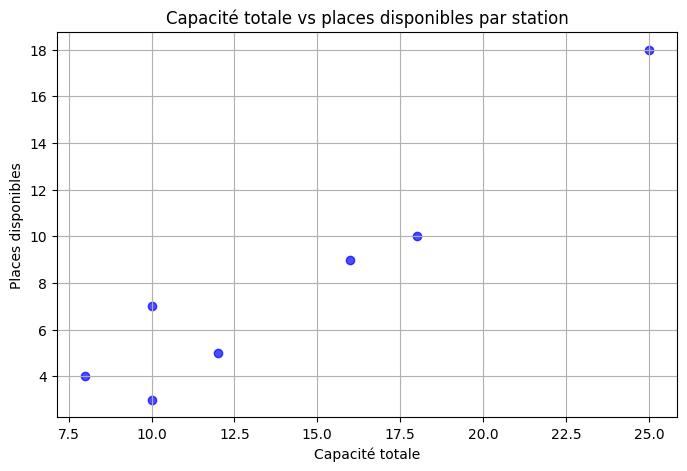

In [80]:
#Scatter plot : relation entre capacité totale et places disponibles

plt.figure(figsize=(8,5))
plt.scatter(df_stations['capacite_totale'], df_stations['places_disponibles'], color='blue', alpha=0.7)
plt.title("Capacité totale vs places disponibles par station")
plt.xlabel("Capacité totale")
plt.ylabel("Places disponibles")
plt.grid(True)
plt.show()

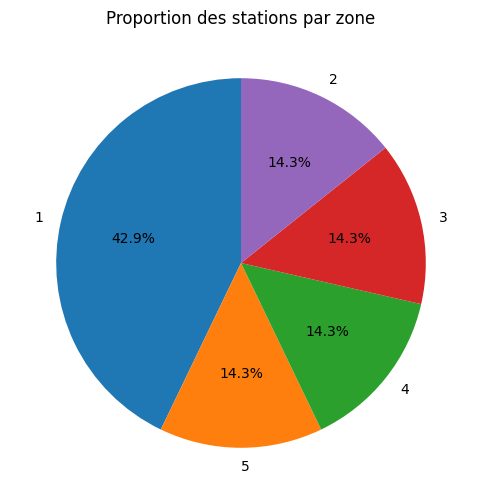

In [81]:
plt.figure(figsize=(6,6))
df_stations['zone_id'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Proportion des stations par zone")
plt.ylabel("") 
plt.show()

## 5. Analyse croisée

**À faire :** Croisez des données provenant d'au moins deux tables en utilisant pandas (`.merge()`) ou une requête SQL avec jointure dans `read_sql_query`.

Produisez un résultat d'analyse qui répond à une question métier pertinente pour MobiGreen.

> Exemples de questions possibles (adaptez à votre schéma) :
> - Quel est le profil d'utilisation selon le type d'abonnement ?
> - Quelles zones concentrent le plus d'activité ?
> - Y a-t-il une corrélation entre la disponibilité des stations et le nombre de trajets ?

In [97]:
# df_utilisateurs : info utilisateur
# df_abonnements : info abonnement et type
# df_trajets : info trajets avec utilisateur_id

# Fusion abonnements et utilisateurs
df_user_abonnement = df_utilisateurs.merge(
    df_abonnements[['utilisateur_id', 'type']],
    on='utilisateur_id',
    how='left'
)

In [98]:
# Nombre de trajets par utilisateur
trajets_par_user = df_trajets.groupby('utilisateur_id')['trajet_id'].count().reset_index(name='nb_trajets')

# Fusion avec df_user_abonnement
df_user_trajets = df_user_abonnement.merge(trajets_par_user, on='utilisateur_id', how='left')

# Remplacer NaN par 0 pour les utilisateurs sans trajets
#df_user_trajets['nb_trajets'] = df_user_trajets['nb_trajets'].fillna(0)

df_user_trajets.head()
df_user_abonnement.head()

,utilisateur_id,nom,email,mot_de_passe_hash,telephone,date_inscription,consentement_rgpd,actif,solde,created_at,type
0,1,Jean Dupont,jean.dupont@example.com,hash_mdp_1,0612345678,2026-04-02 11:33:09.401614,True,True,150.50,2026-04-02 11:33:09.401614+00:00,pay-as-you-go
1,2,Marie Martin,marie.martin@example.com,hash_mdp_2,0623456789,2026-04-02 11:33:09.401614,True,True,200.00,2026-04-02 11:33:09.401614+00:00,mensuel
2,3,Paul Durand,paul.durand@example.com,hash_mdp_3,0634567890,2026-04-02 11:33:09.401614,False,True,0.00,2026-04-02 11:33:09.401614+00:00,annuel
3,4,Sophie Bernard,sophie.bernard@example.com,hash_mdp_4,0645678901,2026-04-02 11:33:09.401614,True,True,75.20,2026-04-02 11:33:09.401614+00:00,mensuel
4,5,Lucas Petit,lucas.petit@example.com,hash_mdp_5,0656789012,2026-04-02 11:33:09.401614,True,False,10.00,2026-04-02 11:33:09.401614+00:00,pay-as-you-go


            type  nb_utilisateurs  moyenne_trajets  total_trajets
0         annuel                3              2.0              6
1        mensuel                4              2.0              8
2  pay-as-you-go                3              2.0              6


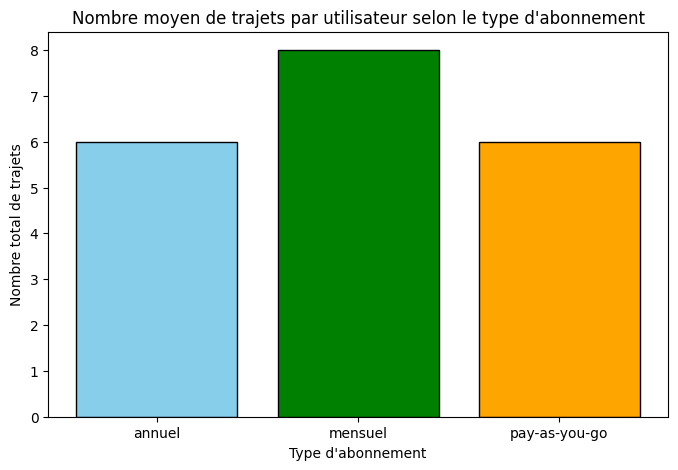

In [99]:
profil_abonnement = df_user_trajets.groupby('type')['nb_trajets'].agg(
    nb_utilisateurs='count',
    moyenne_trajets='mean',
    total_trajets='sum'
).reset_index()

print(profil_abonnement)

plt.figure(figsize=(8,5))
plt.bar(profil_abonnement['type'], profil_abonnement['total_trajets'], color=['skyblue', 'green', 'orange'], edgecolor='black')
plt.title("Nombre moyen de trajets par utilisateur selon le type d'abonnement")
plt.xlabel("Type d'abonnement")
plt.ylabel("Nombre total de trajets")
plt.show()

---
## Récapitulatif — Ce que vous avez mis en œuvre

| Concept | Méthode pandas | ✅ Testé |
|---|---|---|
| Chargement depuis SQL | `pd.read_sql_query()` | ☐ |
| Aperçu des données | `.head()` / `.shape` / `.info()` | ☐ |
| Statistiques | `.describe()` | ☐ |
| Valeurs manquantes | `.isnull().sum()` | ☐ |
| Comptage catégories | `.value_counts()` | ☐ |
| Agrégation | `.groupby().agg()` | ☐ |
| Jointure pandas | `.merge()` | ☐ |
| Visualisation | `matplotlib` | ☐ |

---
**Suite :** `notebook_03_sqlalchemy_intro.ipynb`